<a href="https://colab.research.google.com/github/bogdangit-art/task_modul_5/blob/main/notebooks/EDA_TASK5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza exploratorie a datelor

Scopul acestei analize exploratorii a datelor este de a intelege structura si calitatea setului de date privind mașinile second-hand, inainte de a construi un model de invatare automata.

Variabila tinta este `priceUSD`, care reprezinta pretul unei masini second-hand in USD.

Analiza EDA se concentreaza pe:
- intelegerea dimensiunii si structurii setului de date;
- identificarea variabilelor numerice si categorice;
- verificarea existentei valorilor lipsa;
- examinarea variabilei tinta;
- identificarea valorilor neobisnuite sau potential invalide;
- intelegerea distributiei caracteristicilor importante;
- investigarea relatiilor dintre caracteristicile masinii si pret.

Observatiile rezultate din aceasta analiza vor fi utilizate ulterior pentru a ghida etapele de curatare a datelor, inginerie a caracteristicilor, preprocesare si selectie a modelului.

## Cuprins:

1. Incarcarea bibliotecilor si a setului de date <br>
2. O prima vizualizare a datelor <br>
3. Dimensiunea dataset-ului <br>
4. Numele coloanelor <br>
5. Inspectarea tipurilor de date <br>
6. Verificarea valorilor lipsa <br>
7. Verificarea valorilor lipsa nereprezentate <br>
8. Separarea coloanelor numerice de cele categoriale <br>
9. Investigarea coloanei tinta <br>
10. Vizualizarea distributiei pretului - histograma <br>
11. Vizualizarea distributiei pretului - boxplot <br>
12. Analiza coloanelor numerice <br>
13. Histogramele coloanelor numerice <br>
14. Boxplot-urile coloanelor numerice <br>
15. Investigarea valorilor suspicioase <br>
16. Analiza coloanelor categoriale <br>
&emsp;16.1. Numarul valorilor unice <br>
17. Relatia dintre pret si coloanele numerice <br>
&emsp;17.1. Pret vs an de fabricatie <br>
&emsp;17.2. Pret vs kilometraj <br>
&emsp;17.3. Pret vs capacitate cilindrica <br>
&emsp;17.4. Pret vs kilometraj - vizualizare filtrata <br>
&emsp;17.5. Pret vs capacitate cilindrica - vizualizare filtrata <br>
&emsp;17.6. Matricea de corelatie <br>
18. Relatia dintre pret si coloanele categoriale <br>
&emsp;18.1. Pret vs starea masinii <br>
&emsp;18.2. Pret vs tipul de combustibil, transmisie, tractiune si segment <br>
&emsp;18.3. Pret vs marca <br>
&emsp;18.4. Pret vs model <br>
19. Cautarea duplicatelor <br>
20. Cautarea preturilor extreme <br>
&emsp;20.1. Preturi foarte mici <br>
&emsp;20.2. Preturi foarte mari <br>
21. Concluzii EDA

# 1.Incarcarea bibliotecilor necesare python si a setului de date.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load dataset from GitHub
url = "https://raw.githubusercontent.com/bogdangit-art/task_modul_5/main/data/cars.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 2.O prima vizualizare a datelor.

In acest pas vom observa:

- Primele 5 randuri ale dataset-ului;

- un esantion de 5 intrari aleatorii;

- sfarsitul dateset-ului.

In [2]:
df.head()



,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


In [3]:
df.sample(5, random_state=42)



,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
19270,mitsubishi,carisma,2050,1999,with mileage,250000.0,petrol,1800.0,blue,mechanics,front-wheel drive,M
25927,ford,fusion,4500,2006,with mileage,160000.0,petrol,1400.0,burgundy,mechanics,front-wheel drive,M
23388,mercedes-benz,e-klass,3500,1999,with mileage,485000.0,diesel,2900.0,blue,mechanics,rear drive,E
53189,bmw,x3,21000,2013,with mileage,159000.0,diesel,2000.0,black,auto,NaN,J
34058,renault,megane,3990,2002,with mileage,331700.0,diesel,1900.0,other,mechanics,front-wheel drive,C


In [4]:
df.tail()

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
56239,lancia,zeta,3650,2000,with mileage,290000.0,petrol,2000.0,other,mechanics,front-wheel drive,M
56240,lancia,zeta,4100,1999,with mileage,340000.0,diesel,2100.0,blue,mechanics,front-wheel drive,M
56241,lancia,zeta,3600,1997,with mileage,354000.0,diesel,2100.0,burgundy,mechanics,front-wheel drive,M
56242,lancia,zeta,3000,1997,with mileage,350000.0,petrol,2000.0,blue,mechanics,front-wheel drive,M
56243,lancia,zeta,2950,1996,with mileage,3.0,petrol,2000.0,burgundy,mechanics,front-wheel drive,M


# 3.Dimensiunea dateset-ului.

In acest pas vom afisa dimensiunea pe coloane si randuri a dateset-ului.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 56244
Number of columns: 12


# 4.Numele coloanelor.

Acest dataset contine informatii despre brand-uri, modele, preturi, anul de fabricatie, stare actuala, kilometraj, tip de combustibil, capacitatea cilindrica a motorului, culoare, tipul de transmisie, segmentul in care se incadreaza vehiculul.

In [6]:
print(df.columns)
print(df.columns.tolist())

Index(['make', 'model', 'priceUSD', 'year', 'condition', 'mileage(kilometers)',
       'fuel_type', 'volume(cm3)', 'color', 'transmission', 'drive_unit',
       'segment'],
      dtype='object')
['make', 'model', 'priceUSD', 'year', 'condition', 'mileage(kilometers)', 'fuel_type', 'volume(cm3)', 'color', 'transmission', 'drive_unit', 'segment']


# 5.Inspectarea tipurilor de date din dataset.

In acest dataset avem date de tip numerice precum pretul, anul de productie, etc si categoriale precum model, stare actuala, tip de combustibil, etc.

In [7]:
df.info()

print("\nData types:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  object 
 1   model                56244 non-null  object 
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  object 
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  object 
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  object 
 9   transmission         56244 non-null  object 
 10  drive_unit           54339 non-null  object 
 11  segment              50953 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.1+ MB

Data types:
make                    object
model                   object
priceUSD                 int64
year                   

# 6.Verificarea valorilor lipsa din dataset.

Dupa cum observam acest dataset are valori lipsa in urmatoarele categorii:

- volume(cm) -43 de valori;

- drive_unit -1905 valori;

- segment -5291 valori.

In [8]:
missing_values = df.isna().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
volume(cm3)      47
drive_unit     1905
segment        5291
dtype: int64


# 7.Verificarea valorilor lipsa nereprezentate.
-in acest pas vom verifica setul de date pentru a descoperi daca sunt valori care in realitate lipsesc de tip NaN,nan,NULL,null, etc.

In [9]:
missing_like_values = [
    "",
    " ",
    "NaN",
    "nan",
    "NULL",
    "null",
    "None",
    "none"
]

for column in df.columns:
    if df[column].dtype == "object":
        count = (
            df[column]
            .astype(str)
            .str.strip()
            .isin(missing_like_values)
            .sum()
        )

        if count > 0:
            print(f"{column}: {count}")

drive_unit: 1905
segment: 5291


# 8. Separarea coloanelor numerice de cele categoriale.
In acest caz avem urmatoarele coloane:

Coloane numerice:
['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']

Coloane categoriale:
['make', 'model', 'condition', 'fuel_type', 'color',
 'transmission', 'drive_unit', 'segment']

In [10]:
numeric_columns = [
    "priceUSD",
    "year",
    "mileage(kilometers)",
    "volume(cm3)"
]

categorical_columns = [
    "make",
    "model",
    "condition",
    "fuel_type",
    "color",
    "transmission",
    "drive_unit",
    "segment"
]

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']

Categorical columns:
['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']


# 9. Investigarea categoriei tinta.

In acest caz vom investiga categoria tinta "priceUSD" pentru a descoperi eventuale valori eronate.

Putem observa urmatoarele lucruri:

- minim de $48;

- median de $5,350;

- mean  de $7,415;

- maximum de #235,235.

Aceste valori pot sugera ca distributia pretului poate sa fie afectata de masinile cu pret mare.

In [11]:
df["priceUSD"].describe()

,priceUSD
count,56244.000000
mean,7415.456440
std,8316.959261
min,48.000000
25%,2350.000000
50%,5350.000000
75%,9807.500000
max,235235.000000


# 10.Vizualizarea distributiei  pretului intr-o histograma.

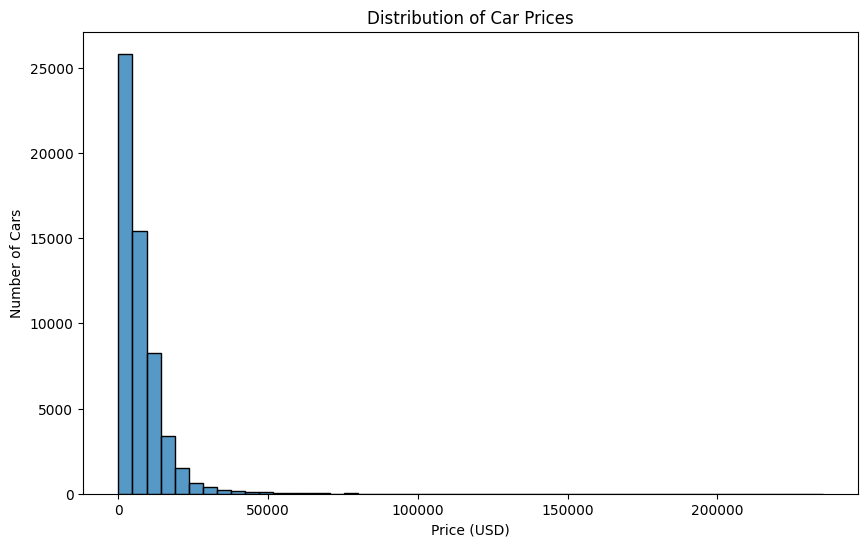

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="priceUSD",
    bins=50
)

plt.title("Distribution of Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")

plt.show()

# 11.Vizualizarea distributiei pretului intr-un boxplot.

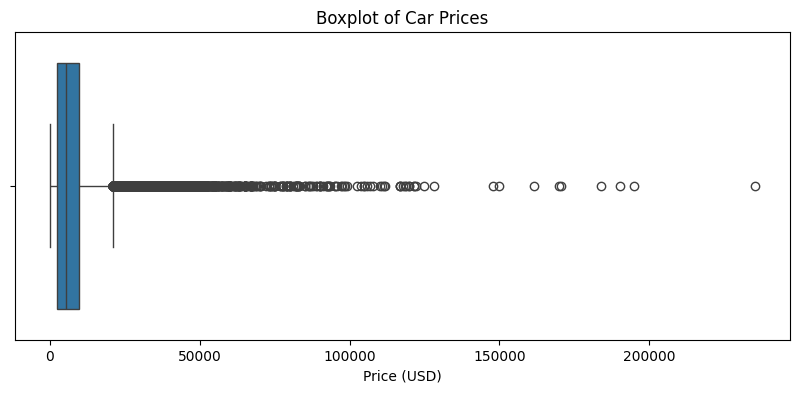

In [13]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["priceUSD"]
)

plt.title("Boxplot of Car Prices")
plt.xlabel("Price (USD)")

plt.show()

# 12.Analiza categoriilor numerice.

### Coloanele numerice – Observatii initiale

Rezumatul statistic evidentiaza cateva caracteristici care necesita investigatii suplimentare:

- `priceUSD` prezinta o asimetrie pozitiva (spre dreapta), intrucat pretul mediu (7.415 USD) este mai mare decat mediana (5.350 USD). Pretul maxim de 235.235 USD depaseste semnificativ quartila superioara si ar putea reprezenta o valoare extrema.
- `year` variaza intre 1910 și 2019. Valoarea minima de 1910 este neobișnuit de scazuta si necesita investigare.
- `mileage(kilometers)` are o mediana de 228.500 km, dar o valoare maxima de 9.999.999 km, ceea ce indica prezenta unor valori potential extreme si nerealiste pentru rulaj.
- `volume(cm3)` inregistreaza 47 de valori lipsa si variaza intre 500 cm³ si 20.000 cm³. Valoarea maxima ar trebui, de asemenea, investigata.


In [14]:
print("Numerical columns analysis:")

df[numeric_columns].describe()






Numerical columns analysis:


,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


# 13. Afisarea in histograma a coloanelor numerice.

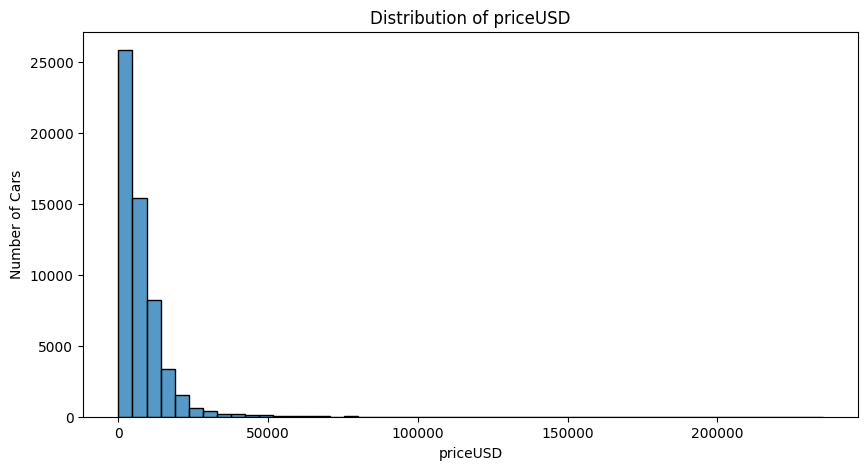

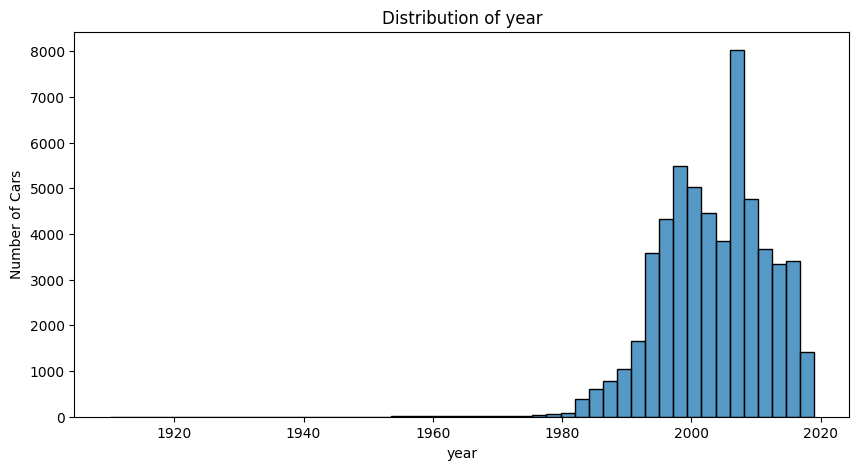

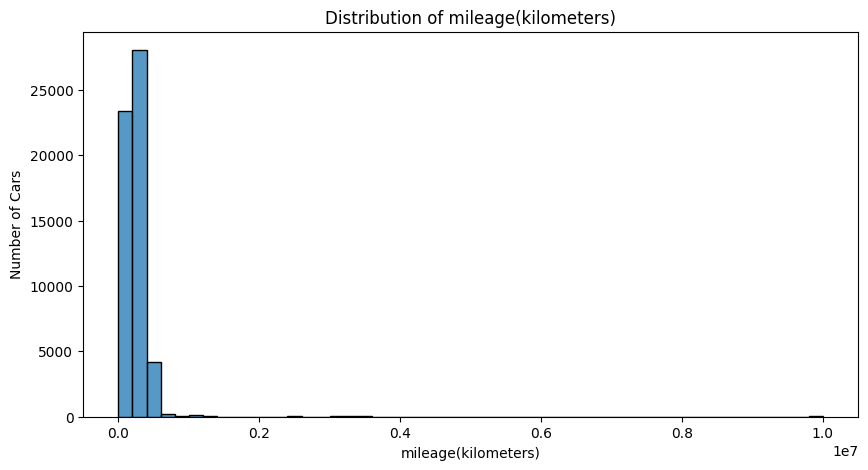

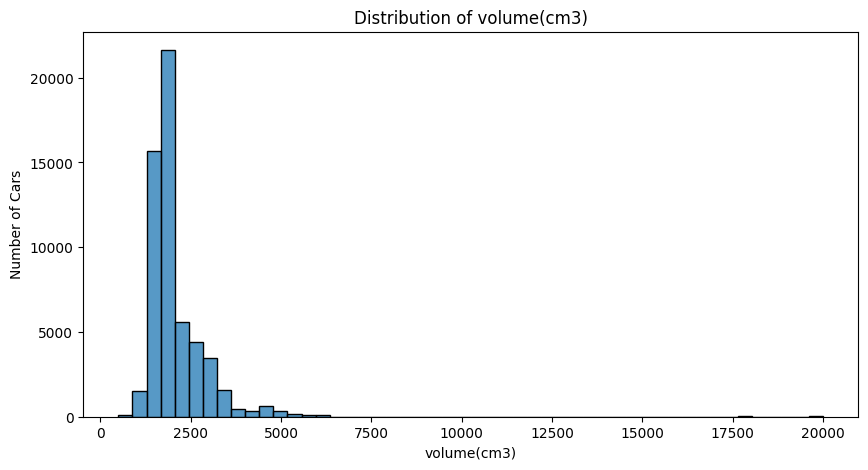

In [15]:
for column in numeric_columns:
    plt.figure(figsize=(10, 5))

    sns.histplot(data=df, x=column, bins=50)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Cars")
    plt.show()

# 14. Afisarea in boxplot a coloanelor numerice.

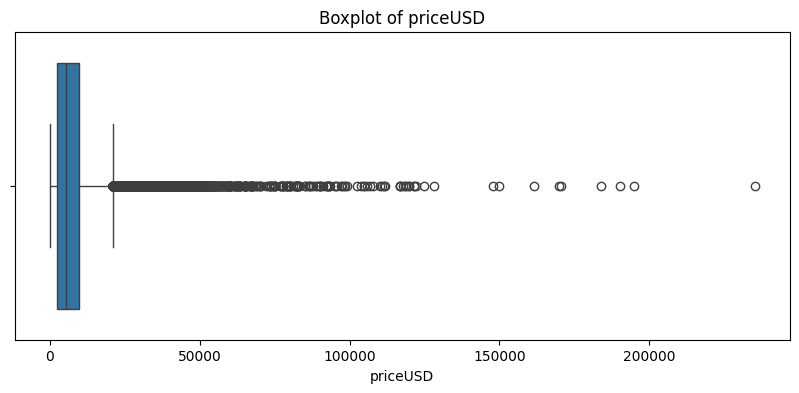

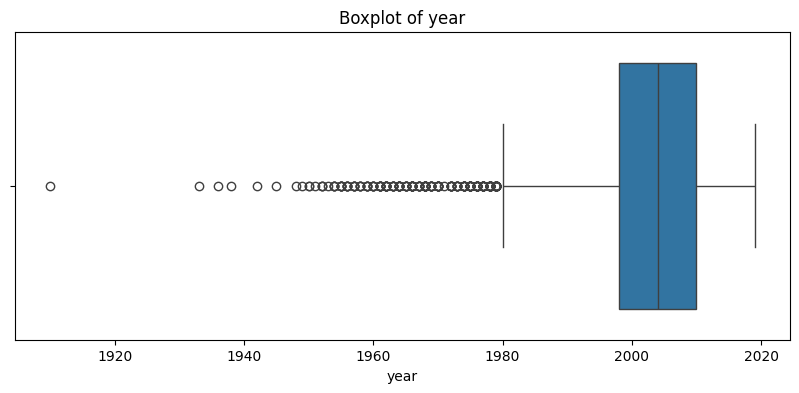

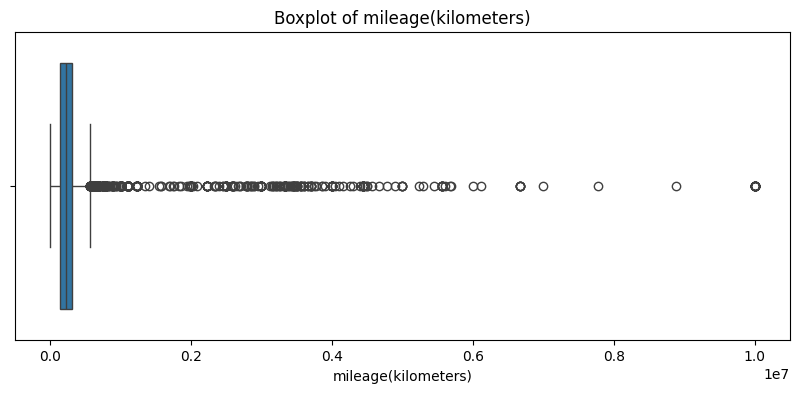

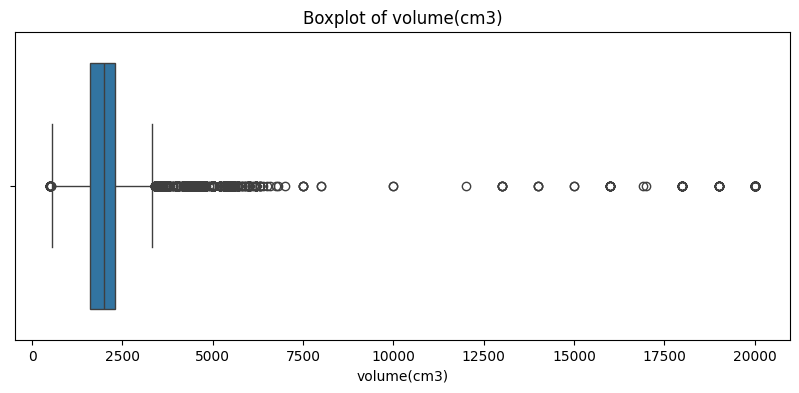

In [16]:
for column in numeric_columns:
    plt.figure(figsize=(10, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

# 15.Investigarea valorilor suspicioase.

In [17]:
print("Masini cu un kilometraj foarte mare:")

df[df["mileage(kilometers)"] > 1_000_000][
    ["make", "model", "year", "priceUSD", "mileage(kilometers)"]
].sort_values("mileage(kilometers)", ascending=False)

Masini cu un kilometraj foarte mare:


,make,model,year,priceUSD,mileage(kilometers)
1854,audi,100,1989,900,9999999.0
5783,peugeot,806,2000,4100,9999999.0
36926,opel,omega,1987,400,9999999.0
6465,lada-vaz,2108,1990,295,9999999.0
6114,lada-vaz,2104,1990,600,9999999.0
...,...,...,...,...,...
1980,audi,100,1989,550,1111111.0
983,renault,25,1985,700,1111111.0
1112,audi,80,1984,700,1111111.0
893,gaz,21,1968,600,1111111.0


In [18]:
print("Masini cu an foarte vechi de productie:")

df[df["year"] < 1980][
    ["make", "model", "year", "priceUSD", "mileage(kilometers)"]
].sort_values("year")

Masini cu an foarte vechi de productie:


,make,model,year,priceUSD,mileage(kilometers)
5952,zaz,968,1910,48,25000.0
43024,eksklyuziv,retro,1933,50000,1.0
43020,eksklyuziv,retro,1936,4991,175000.0
43025,eksklyuziv,retro,1938,12500,100000.0
42986,eksklyuziv,redkaya-model,1942,17000,40000.0
...,...,...,...,...,...
7515,volvo,240-series,1979,8500,140000.0
23438,mercedes-benz,e-klass,1979,2200,300000.0
28296,ford,granada,1979,1500,71000.0
953,gaz,24,1979,238,50000.0


In [19]:
print("Masini cu motoare foarte mari:")

df[df["volume(cm3)"] > 6000][
    ["make", "model", "year", "priceUSD", "volume(cm3)"]
].sort_values("volume(cm3)", ascending=False)

Masini cu motoare foarte mari:


,make,model,year,priceUSD,volume(cm3)
81,mazda,3,2006,5300,20000.0
354,mazda,6,2003,7500,20000.0
1537,audi,80,1993,2900,20000.0
1768,audi,100,1992,2150,20000.0
5908,volvo,940,1997,1521,20000.0
...,...,...,...,...,...
23764,cadillac,escalade,2015,47400,6200.0
43924,mercedes-benz,s-klass-amg,2008,28500,6200.0
48054,chevrolet,suburban,1983,7130,6200.0
23768,cadillac,escalade,2007,15000,6156.0


In [20]:
print("Kilometraj > 1,000,000 km:",
      (df["mileage(kilometers)"] > 1_000_000).sum())

print("An de fabricatie< 1980:",
      (df["year"] < 1980).sum())

print("Capacitate cilindrica > 6,000 cm3:",
      (df["volume(cm3)"] > 6_000).sum())

Kilometraj > 1,000,000 km: 364
An de fabricatie< 1980: 258
Capacitate cilindrica > 6,000 cm3: 122


# 16. Analiza coloanelor categoriale.

### Constatari initiale

Setul de date contine variabile categoriale cu niveluri foarte diferite de cardinalitate.

* `make` contine 96 de producatori unici. Mai multi producatori apar foarte frecvent, in timp ce unii apar o singura data.
* `model` contine 1.034 de valori unice, ceea ce o face o caracteristica categoriala cu o cardinalitate ridicata. Acest aspect va necesita atentie in etapa de preprocesare, deoarece aplicarea One-Hot Encoding poate genera un numar mare de caracteristici suplimentare.
* `condition` contine trei categorii si este puternic dominata de masinile clasificate ca `with mileage`.
* `fuel_type` contine trei categorii: `petrol`, `diesel` si `electrocar`. Masinile electrice sunt foarte rare in setul de date.
* `color` contine 13 categorii, fara inconsistente evidente in valorile cele mai frecvente.
* `transmission` contine doar doua categorii: `mechanics` si `auto`.
* `drive_unit` contine patru categorii, dar are si 1.905 valori lipsa.
* `segment` contine noua categorii si are 5.291 de valori lipsa.

In general, valorile categoriale par sa fie standardizate corespunzator. Totusi, valorile lipsa din `drive_unit` si `segment`, categoriile rare, precum si cardinalitatea ridicata a variabilei `make` si in special a variabilei `model` vor trebui luate in considerare in etapa de preprocesare.


## 16.1 Numarul valorilor unice.

In [21]:
print("Numarul valorilor unice:")

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print("-" * 40)
    print("Valori unice:", df[column].nunique())
    print(df[column].value_counts(dropna=False).head(20))

Numarul valorilor unice:

MAKE
----------------------------------------
Valori unice: 96
make
volkswagen       6861
audi             4030
bmw              4013
opel             3779
renault          3713
mercedes-benz    3541
ford             3078
peugeot          2876
nissan           2233
toyota           2177
mazda            2006
citroen          1991
hyundai          1499
mitsubishi       1350
volvo            1232
kia              1196
skoda            1143
lada-vaz         1004
honda             949
fiat              939
Name: count, dtype: int64

MODEL
----------------------------------------
Valori unice: 1034
model
passat         2086
5-seriya       1476
a6             1276
golf           1070
astra          1013
e-klass         988
3-seriya        823
vectra          815
laguna          768
mondeo          731
a4              704
scenic          628
zafira          592
100             582
transporter     571
7-seriya        563
megane          542
x5              537
focus  

## 17. Relatia dintre pret si coloanele numerice.

### Relatia dintre pret si anul de fabricatie

Graficul indica o relatie pozitiva intre anul de fabricatie si pretul masinii. In general, masinile mai noi tind sa aiba preturi mai ridicate, in timp ce masinile mai vechi sunt concentrate in zona preturilor mai reduse.

Se observa totusi o variatie considerabila a preturilor pentru acelasi an de fabricatie. Acest lucru indica faptul ca anul de fabricatie este o caracteristica importanta pentru estimarea pretului, dar nu poate explica singur pretul unei masini.

Pretul este probabil influentat simultan si de alte caracteristici, precum marca, modelul, kilometrajul, capacitatea cilindrica si starea masinii.

### Relatia dintre pret si kilometraj

Graficul indica o relatie negativa intre kilometraj si pret. Masinile cu un kilometraj redus prezinta o variatie mare a preturilor si includ cele mai scumpe masini din setul de date.

Pe masura ce kilometrajul creste, preturile tind sa fie mai mici, iar valorile sunt concentrate tot mai mult in zona preturilor reduse.

Relatia dintre kilometraj si pret nu pare sa fie perfect liniara. Acest lucru sugereaza ca efectul kilometrajului asupra pretului poate fi mai complex si poate interactiona cu alte caracteristici ale masinii, precum anul de fabricatie, marca sau modelul.


### Relatia dintre pret si capacitatea cilindrica

Graficul arata ca masinile sunt concentrate in jurul unor capacitati cilindrice specifice, ceea ce reflecta valorile standard ale motoarelor existente pe piata.

Se poate observa o tendinta generala ca masinile cu motoare mai mari sa poata avea preturi mai ridicate. Totusi, exista o variatie considerabila a pretului pentru aceeasi capacitate cilindrica.

Prin urmare, capacitatea cilindrica pare sa contina informatie utila pentru estimarea pretului, dar nu este suficienta singura pentru a explica diferentele de pret dintre masini.

In [22]:
correlation_columns = [
    "priceUSD",
    "year",
    "mileage(kilometers)",
    "volume(cm3)"
]

df[correlation_columns].corr()

,priceUSD,year,mileage(kilometers),volume(cm3)
priceUSD,1.000000,0.605131,-0.170933,0.267553
year,0.605131,1.000000,-0.233049,0.027370
mileage(kilometers),-0.170933,-0.233049,1.000000,0.013452
volume(cm3),0.267553,0.027370,0.013452,1.000000


## 17.1 Pret vs an de fabricatie.

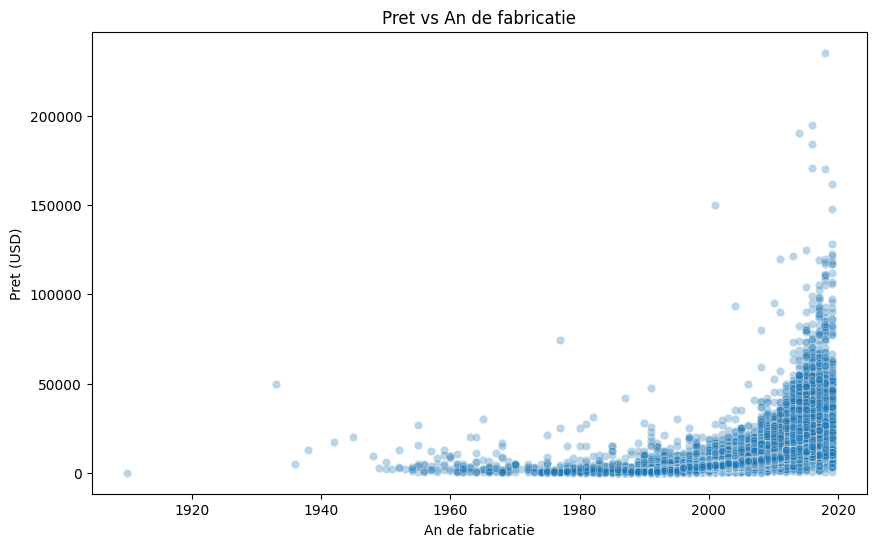

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="year",
    y="priceUSD",
    alpha=0.3
)

plt.title("Pret vs An de fabricatie")
plt.xlabel("An de fabricatie")
plt.ylabel("Pret (USD)")
plt.show()

## 17.2 Pret vs kilometraj.

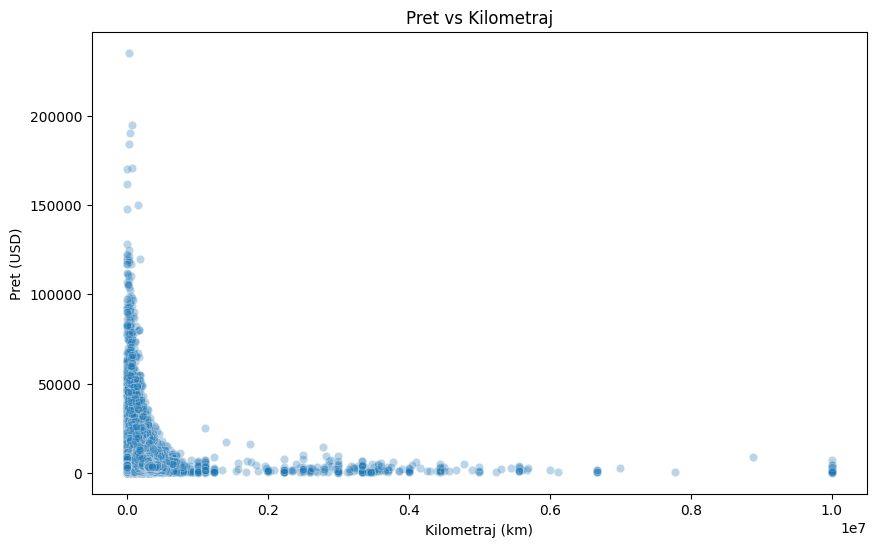

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="mileage(kilometers)",
    y="priceUSD",
    alpha=0.3
)

plt.title("Pret vs Kilometraj")
plt.xlabel("Kilometraj (km)")
plt.ylabel("Pret (USD)")
plt.show()

## 17.3  Pret vs Capacitate cilindrica.

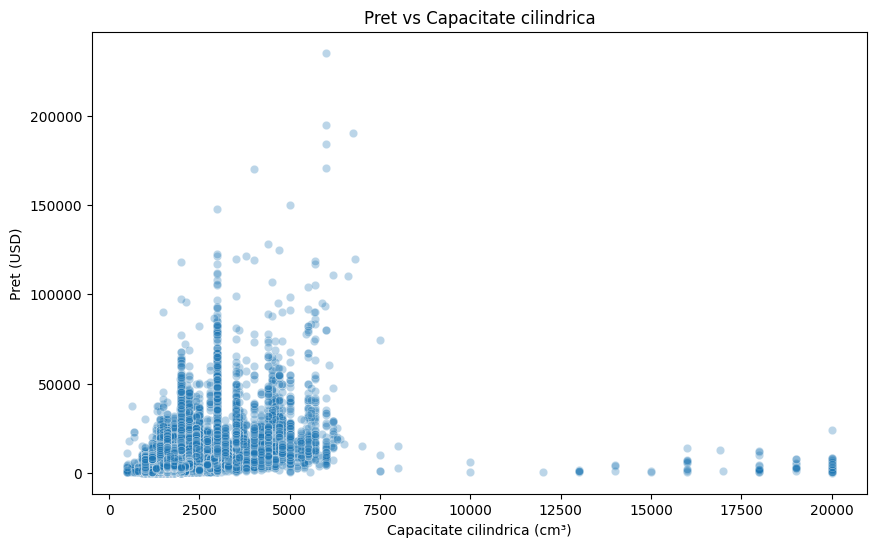

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="volume(cm3)",
    y="priceUSD",
    alpha=0.3
)

plt.title("Pret vs Capacitate cilindrica")
plt.xlabel("Capacitate cilindrica (cm³)")
plt.ylabel("Pret (USD)")
plt.show()

## 17.4 Pret vs kilometraj - vizualizare filtrata.

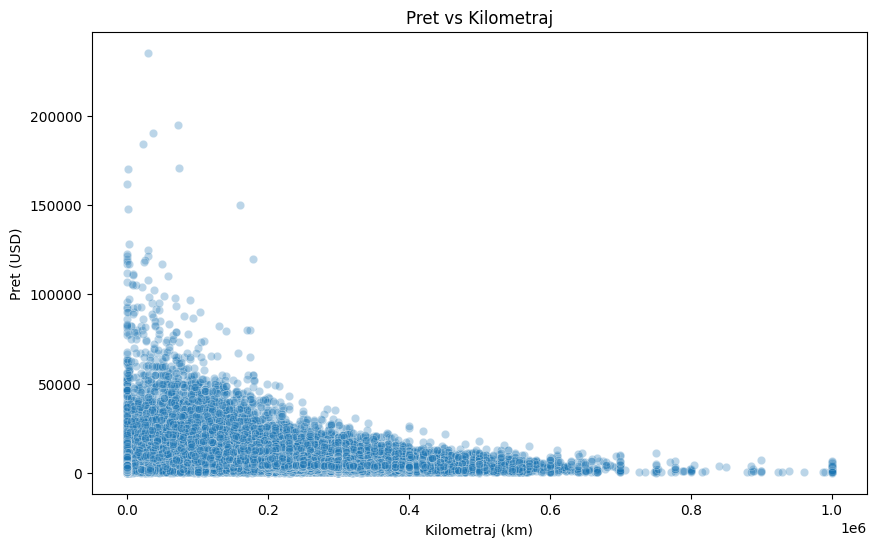

In [26]:
# Filtrare doar pentru vizualizare
mileage_plot_df = df[df["mileage(kilometers)"] <= 1_000_000]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=mileage_plot_df,
    x="mileage(kilometers)",
    y="priceUSD",
    alpha=0.3
)

plt.title("Pret vs Kilometraj")
plt.xlabel("Kilometraj (km)")
plt.ylabel("Pret (USD)")
plt.show()

## 17.5 Pret vs capacitate cilindrica - vizualizare filtrata.

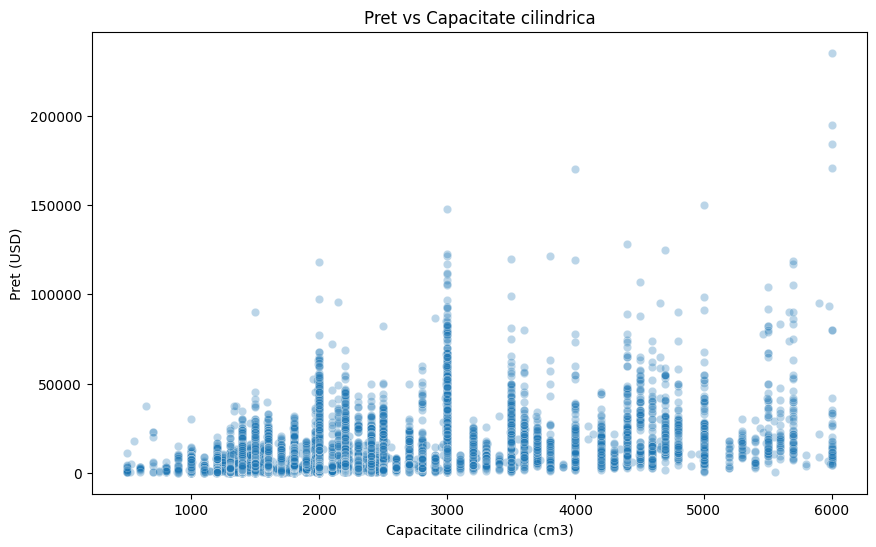

In [27]:
# Filtrare doar pentru vizualizare
volume_plot_df = df[df["volume(cm3)"] <= 6000]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=volume_plot_df,
    x="volume(cm3)",
    y="priceUSD",
    alpha=0.3
)

plt.title("Pret vs Capacitate cilindrica")
plt.xlabel("Capacitate cilindrica (cm3)")
plt.ylabel("Pret (USD)")
plt.show()

## 17.6 Matricea de corelatie.

### Analiza corelatiilor dintre variabilele numerice

Matricea de corelatie confirma o parte dintre relatiile observate anterior in grafice.

- `year` prezinta cea mai puternica relatie liniara cu `priceUSD`, avand un coeficient de corelatie de aproximativ 0.61. Acest rezultat indica faptul ca masinile mai noi tind sa aiba preturi mai ridicate.
- `mileage(kilometers)` are o corelatie negativa slaba cu pretul, de aproximativ -0.17. In general, un kilometraj mai mare este asociat cu un pret mai redus. Totusi, graficul analizat anterior sugereaza ca relatia nu este perfect liniara, iar valorile extreme ale kilometrajului pot influenta coeficientul de corelatie.
- `volume(cm3)` prezinta o corelatie pozitiva slaba cu pretul, de aproximativ 0.27. Masinile cu motoare mai mari pot avea preturi mai ridicate, dar capacitatea cilindrica nu explica singura diferentele de pret.

Rezultatele arata ca niciuna dintre caracteristicile numerice analizate nu explica singura pretul unei masini. Pretul este influentat de combinatia mai multor caracteristici numerice si categoriale.

De asemenea, coeficientul de corelatie masoara in principal relatia liniara dintre doua variabile. Prin urmare, o corelatie liniara slaba nu inseamna automat ca o caracteristica nu este utila pentru un model de machine learning.

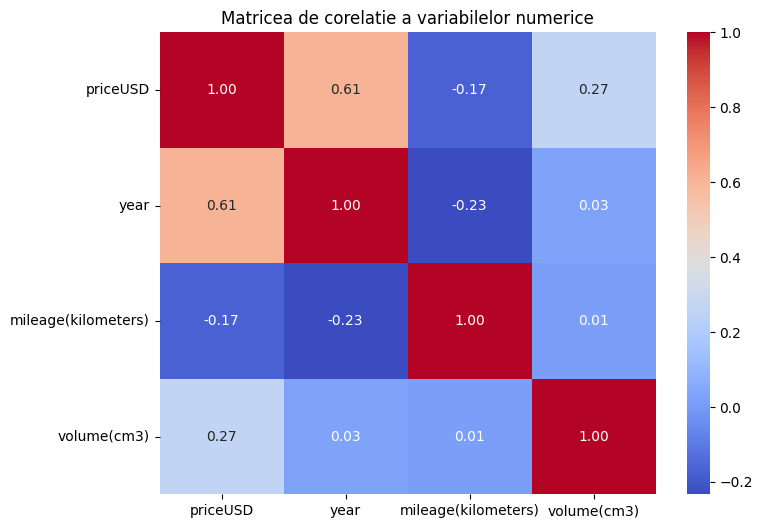

In [28]:
correlation_columns = [
    "priceUSD",
    "year",
    "mileage(kilometers)",
    "volume(cm3)"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matricea de corelatie a variabilelor numerice")
plt.show()

## 18. Relatia dintre pret si coloanele categoriale.

## 18.1 Pret vs starea masinii.

Graficul arata diferente clare intre distributiile preturilor pentru cele trei categorii ale variabilei `condition`.

Masinile din categoria `with mileage` prezinta cea mai mare variatie a preturilor si includ majoritatea masinilor cu preturi ridicate. Aceasta categorie este si cea mai frecventa in setul de date.

Masinile din categoria `with damage` tind sa aiba preturi mai reduse, iar masinile clasificate ca `for parts` sunt concentrate in zona celor mai mici preturi.

Aceste diferente sugereaza ca starea masinii contine informatie relevanta pentru estimarea pretului si ar trebui pastrata ca variabila de intrare pentru modelele de machine learning.

Trebuie luat in considerare si faptul ca variabila `condition` este puternic dezechilibrata, deoarece majoritatea observatiilor apartin categoriei `with mileage`.

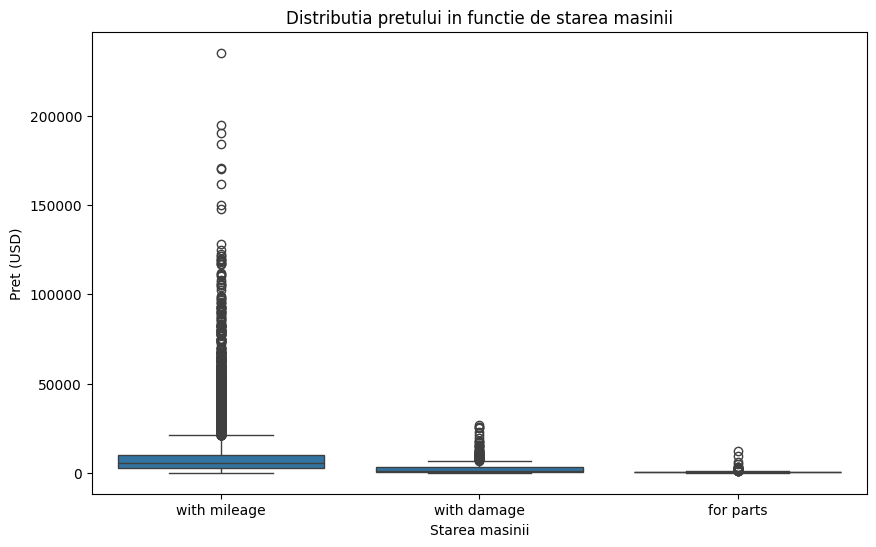

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="condition",
    y="priceUSD"
)

plt.title("Distributia pretului in functie de starea masinii")
plt.xlabel("Starea masinii")
plt.ylabel("Pret (USD)")
plt.show()

## 18.2 Pret in functie de combustibil, transmisie, tractiune si segment.

### Relatia dintre pret si tipul de combustibil

Graficul arata diferente intre distributiile preturilor pentru cele trei categorii ale variabilei `fuel_type`.

Masinile pe benzina (`petrol`) sunt concentrate in general in zona preturilor mai reduse, desi exista si numeroase valori extreme cu preturi ridicate.

Masinile diesel (`diesel`) prezinta in general preturi ceva mai ridicate comparativ cu masinile pe benzina.

Masinile electrice (`electrocar`) prezinta un pret median considerabil mai ridicat si o variatie mare a preturilor. Totusi, aceasta categorie contine doar 47 de observatii, comparativ cu 36.405 masini pe benzina si 19.792 masini diesel. Din acest motiv, rezultatele pentru categoria `electrocar` trebuie interpretate cu prudenta.

Diferentele observate sugereaza ca tipul de combustibil poate contine informatie relevanta pentru estimarea pretului si ar trebui luat in considerare ca variabila de intrare pentru modelele de machine learning.

### Relatia dintre pret si tipul transmisiei

Graficul arata o diferenta clara intre distributiile preturilor pentru cele doua tipuri de transmisie.

Masinile cu transmisie automata (`auto`) tind sa aiba preturi mai ridicate comparativ cu masinile cu transmisie manuala (`mechanics`). De asemenea, categoria `auto` prezinta o variatie mai mare a preturilor si contine mai multe observatii cu preturi ridicate.

Aceste diferente sugereaza ca tipul transmisiei contine informatie relevanta pentru estimarea pretului si ar trebui pastrat ca variabila de intrare pentru modelele de machine learning.

### Relatia dintre pret si tipul tractiunii

Graficul indica diferente intre distributiile preturilor in functie de variabila `drive_unit`.

Masinile cu tractiune integrala (`all-wheel drive`) prezinta in general preturi mai ridicate comparativ cu masinile cu tractiune fata (`front-wheel drive`) sau tractiune spate (`rear drive`).

Categoria `part-time four-wheel drive` prezinta de asemenea preturi relativ ridicate, desi exista o variatie considerabila in interiorul fiecarei categorii.

Rezultatele sugereaza ca tipul tractiunii poate contine informatie utila pentru estimarea pretului masinii. Variabila trebuie pastrata pentru etapa de modelare, iar cele 1.905 valori lipsa identificate anterior vor trebui tratate in etapa de preprocesare.

### Relatia dintre pret si segmentul masinii

Graficul arata diferente intre distributiile preturilor pentru diferitele categorii ale variabilei `segment`.

Segmentele `J`, `S` si `F` prezinta in general preturi mai ridicate, in timp ce segmentul `A` este concentrat in zona preturilor mai reduse.

Pentru celelalte segmente exista o suprapunere considerabila a distributiilor, ceea ce indica faptul ca segmentul masinii nu poate explica singur pretul acesteia.

Totusi, diferentele observate intre categorii sugereaza ca `segment` contine informatie relevanta pentru estimarea pretului si ar trebui pastrat ca variabila de intrare.

Variabila contine si 5.291 de valori lipsa, identificate anterior, care vor trebui tratate in etapa de preprocesare.

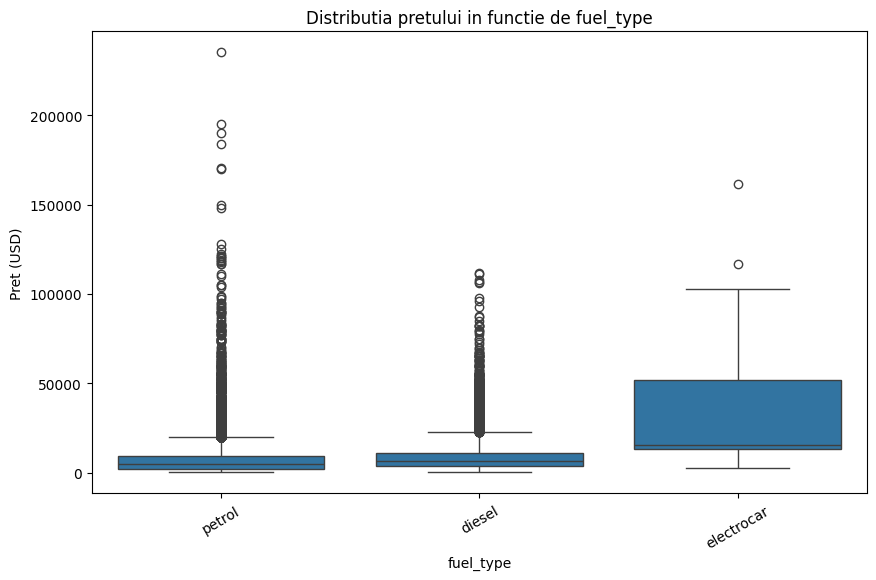

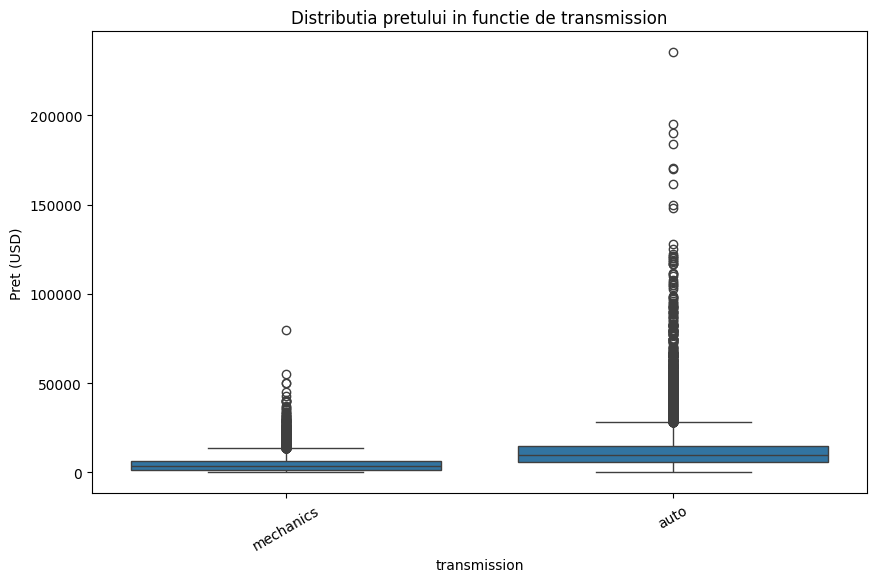

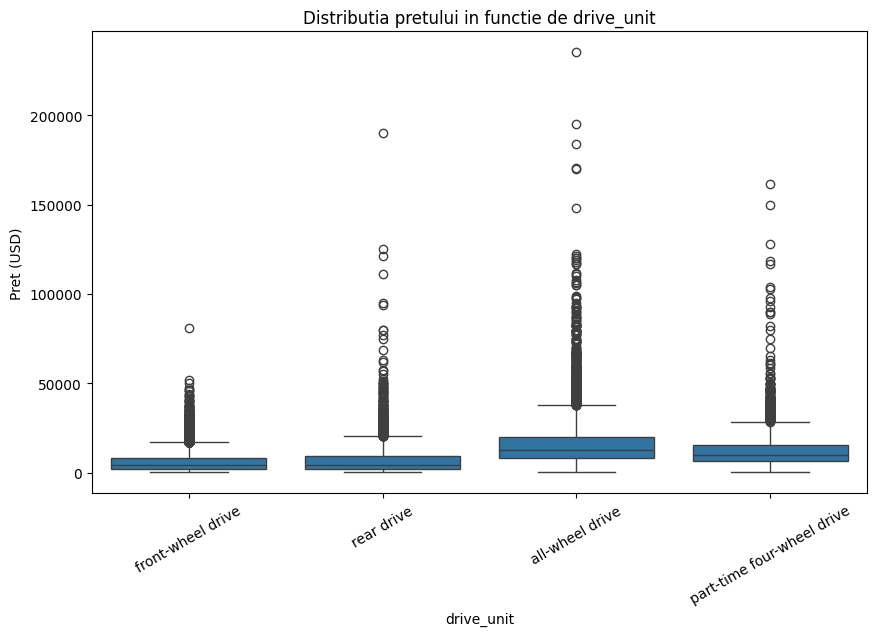

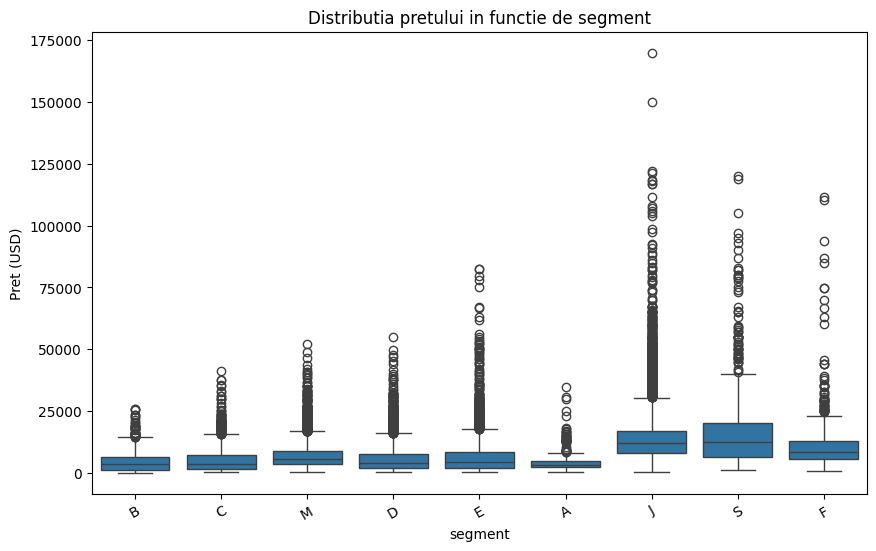

In [30]:
categorical_price_columns = [
    "fuel_type",
    "transmission",
    "drive_unit",
    "segment"
]

for column in categorical_price_columns:
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x=column,
        y="priceUSD"
    )

    plt.title(f"Distributia pretului in functie de {column}")
    plt.xlabel(column)
    plt.ylabel("Pret (USD)")
    plt.xticks(rotation=30)
    plt.show()

## 18.3 Distributia pretului pentru cele mai frecvente marci.


Pentru analiza variabilei `make` au fost reprezentate doar cele mai frecvente 15 marci, deoarece setul de date contine 96 de producatori, iar reprezentarea tuturor acestora intr-un singur grafic ar fi dificil de interpretat.

Graficul arata diferente intre distributiile preturilor pentru diferite marci. Unele marci, precum `bmw`, `mercedes-benz`, `toyota`, `volvo` si `audi`, prezinta in general preturi mai ridicate, in timp ce alte marci sunt concentrate in zone de pret mai reduse.

In acelasi timp, exista o suprapunere considerabila a preturilor intre marci si o variatie mare in interiorul aceleiasi marci. Prin urmare, marca masinii nu poate explica singura pretul acesteia.

Diferentele observate sugereaza ca `make` contine informatie relevanta pentru estimarea pretului si ar trebui luata in considerare in etapa de modelare.

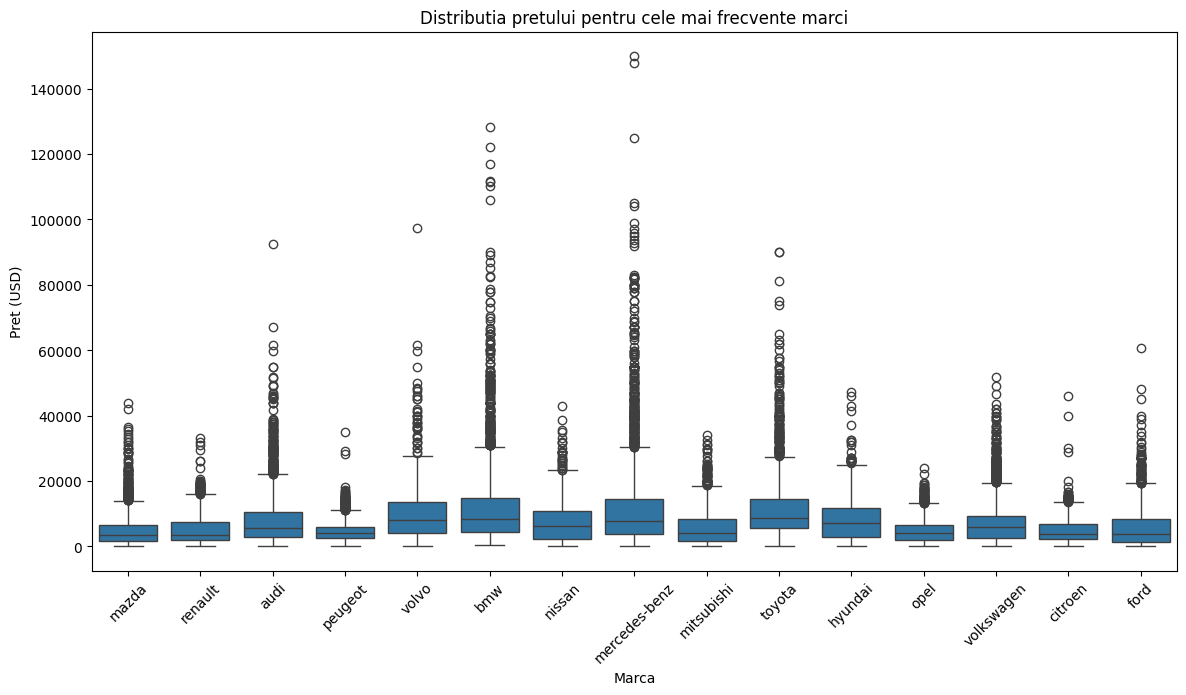

In [31]:
top_makes = df["make"].value_counts().head(15).index

top_makes_df = df[df["make"].isin(top_makes)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_makes_df,
    x="make",
    y="priceUSD"
)

plt.title("Distributia pretului pentru cele mai frecvente marci")
plt.xlabel("Marca")
plt.ylabel("Pret (USD)")
plt.xticks(rotation=45)
plt.show()

## 18.4 Distributia pretului pentru cele mai frecvente modele.

Variabila `model` contine 1.034 de valori unice, astfel incat reprezentarea tuturor modelelor intr-un singur grafic nu ar fi usor de interpretat. Din acest motiv, analiza grafica a fost realizata pentru cele mai frecvente 20 de modele.

Se observa diferente importante intre distributiile preturilor pentru diferite modele. De exemplu, dintre modelele analizate, `x5` prezinta cel mai ridicat pret median, de aproximativ 13.500 USD, in timp ce modelul `100` are un pret median de aproximativ 1.438 USD.

Pentru mai multe modele, pretul mediu este mai mare decat pretul median, ceea ce indica influenta unor masini cu preturi ridicate asupra mediei.

Rezultatele sugereaza ca `model` poate contine informatie importanta pentru estimarea pretului. Totusi, cardinalitatea ridicata a acestei variabile, cu 1.034 de categorii distincte, trebuie luata in considerare in etapa de preprocesare, deoarece aplicarea One-Hot Encoding poate genera un numar mare de caracteristici.

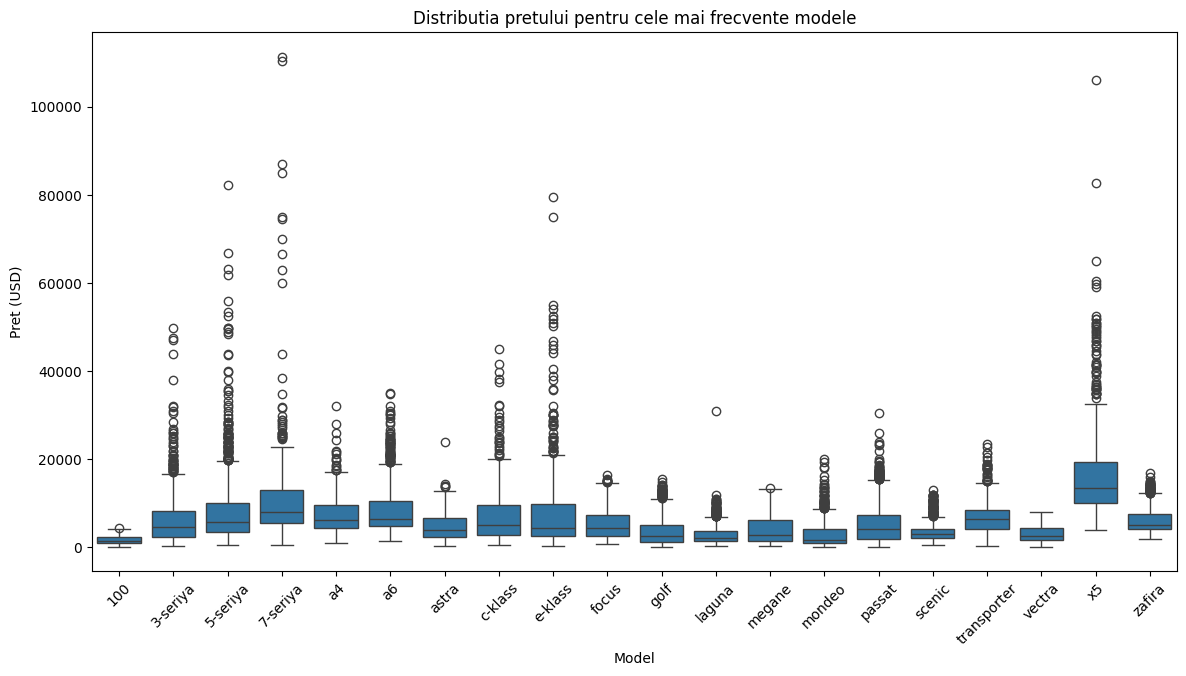

In [32]:
top_models = df["model"].value_counts().head(20).index

top_models_df = df[df["model"].isin(top_models)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_models_df,
    x="model",
    y="priceUSD"
)

plt.title("Distributia pretului pentru cele mai frecvente modele")
plt.xlabel("Model")
plt.ylabel("Pret (USD)")
plt.xticks(rotation=45)
plt.show()

In [33]:
model_price_summary = (
    top_models_df
    .groupby("model")["priceUSD"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

model_price_summary

,count,median,mean
model,,,
x5,537,13500.0,17161.202980
7-seriya,563,8000.0,10998.001776
a6,1276,6500.0,8368.588558
transporter,571,6400.0,6954.866900
a4,704,6150.0,7348.565341
5-seriya,1476,5700.0,8113.174119
zafira,592,5100.0,6377.243243
c-klass,508,5000.0,7386.435039
3-seriya,823,4600.0,6467.620899


## 19. Cautarea duplicatelor.

In [34]:
duplicate_rows = df.duplicated().sum()

print(f"Numarul randurilor duplicate: {duplicate_rows}")

Numarul randurilor duplicate: 87


## 20. Cautarea preturilor extreme.

### Investigarea preturilor foarte mici

Analiza masinilor cu cele mai mici preturi arata ca valorile reduse ale variabilei `priceUSD` nu pot fi considerate automat erori.

Mai multe dintre masinile cu preturi foarte mici sunt clasificate ca `for parts` sau `with damage` si sunt vehicule vechi. In acest context, preturile reduse pot fi plauzibile.

Au fost observate totusi si inregistrari care contin simultan valori neobisnuite pentru alte caracteristici, precum anul de fabricatie sau kilometrajul. Aceste cazuri necesita atentie in etapa de curatare a datelor.

Prin urmare, nu este justificata eliminarea automata a unei masini doar pe baza unui pret foarte mic. Pretul trebuie analizat impreuna cu celelalte caracteristici ale vehiculului.


### Investigarea preturilor foarte mari

Analiza masinilor cu cele mai mari preturi arata ca valorile extreme ale variabilei `priceUSD` par sa fie plauzibile in contextul caracteristicilor vehiculelor.

Cele mai scumpe masini apartin in principal unor marci premium sau de lux, precum `bentley`, `porsche`, `mercedes-benz`, `bmw`, `mclaren`, `lexus`, `land-rover` si `tesla`. De asemenea, majoritatea acestor masini au ani de fabricatie recenti.

De exemplu, cel mai mare pret din setul de date, 235.235 USD, corespunde unui `bentley continental-gt` din anul 2018, cu un kilometraj de 29.000 km.

Prin urmare, preturile foarte mari reprezinta valori extreme, dar analiza inregistrarilor nu ofera suficiente motive pentru a le considera automat erori. Eliminarea valorilor extreme doar pe baza pretului ar putea duce la pierderea unor observatii valide si relevante pentru model.

## 20.1 Preturi foarte mici.

In [35]:
print("Masinile cu cele mai mici preturi:")

df[
    [
        "make",
        "model",
        "year",
        "condition",
        "priceUSD",
        "mileage(kilometers)"
    ]
].sort_values("priceUSD").head(20)

Masinile cu cele mai mici preturi:


,make,model,year,condition,priceUSD,mileage(kilometers)
5952,zaz,968,1910,with damage,48,25000.0
40252,proton,persona,1997,with damage,95,1111.0
24873,ford,fiesta,1992,for parts,100,1.0
5456,mazda,626,1986,with mileage,100,100.0
54171,citroen,xantia,1995,for parts,100,380000.0
20971,toyota,corolla,1988,for parts,100,300000.0
41010,nissan,primera,1994,for parts,100,300000.0
23898,ford,escort,1986,for parts,100,200000.0
7314,mercedes-benz,190-w201,1991,for parts,100,2000.0
7076,lada-vaz,21099,1992,for parts,119,20000.0


## 20.2 Preturi foarte mari.

In [36]:
print("Masinile cu cele mai mari preturi:")

df[
    [
        "make",
        "model",
        "year",
        "condition",
        "priceUSD",
        "mileage(kilometers)"
    ]
].sort_values("priceUSD", ascending=False).head(20)

Masinile cu cele mai mari preturi:


,make,model,year,condition,priceUSD,mileage(kilometers)
20787,bentley,continental-gt,2018,with mileage,235235,29000.0
16430,bentley,bentayga,2016,with mileage,195000,72000.0
35457,bentley,mulsanne,2014,with mileage,190141,36500.0
16428,bentley,bentayga,2016,with mileage,183848,22000.0
16429,bentley,bentayga,2016,with mileage,170477,74100.0
19557,porsche,cayenne,2018,with mileage,170000,1020.0
34508,tesla,model-x,2019,with mileage,161563,50.0
26254,mercedes-benz,g-klass,2001,with mileage,150000,160000.0
33702,mercedes-benz,maybach,2019,with mileage,148000,950.0
33327,bmw,m5,2019,with mileage,128136,2925.0


## 21. Concluzii EDA.


Analiza exploratorie a aratat ca setul de date contine atat variabile numerice, cat si categoriale care pot fi relevante pentru estimarea pretului masinilor.

Au fost identificate valori lipsa in `volume(cm3)`, `drive_unit` si `segment`, precum si valori suspecte pentru kilometraj si capacitatea cilindrica. De asemenea, au fost identificate 87 de randuri duplicate. Aceste aspecte vor fi tratate in etapa de curatare si preprocesare a datelor.

Analiza preturilor extreme a aratat ca acestea nu trebuie eliminate automat. Preturile foarte mici pot fi asociate cu masini vechi, avariate sau vandute pentru piese, iar preturile foarte mari apar in principal la masini premium sau de lux.

Dintre variabilele numerice, `year` prezinta cea mai puternica relatie liniara cu pretul. Kilometrajul si capacitatea cilindrica prezinta de asemenea relatii cu pretul, dar acestea sunt mai slabe si nu par complet liniare.

Variabilele categoriale precum `condition`, `fuel_type`, `transmission`, `drive_unit`, `segment`, `make` si `model` prezinta diferente intre distributiile preturilor si pot oferi informatii utile pentru predictie. `model` necesita atentie suplimentara la preprocesare deoarece contine 1.034 de categorii.

In concluzie, pretul unei masini este influentat de mai multe caracteristici, iar unele relatii par neliniare. Din acest motiv, vor fi comparate mai multe modele de regresie, iar modelul final va fi ales pe baza rezultatelor obtinute folosind MAE, MSE, RMSE si R2.